#SPARSE AUTO ENCODER IMPLEMENTATION

Block 1: Import required libraries

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

Block 2: Check whether GPU is available


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device being used:", device)

Device being used: cpu


Block 3: Define image preprocessing transformations


In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

Block 4: Load CIFAR-10 dataset


In [4]:
train_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

100%|██████████| 170M/170M [00:02<00:00, 74.9MB/s]


Training samples: 50000
Testing samples: 10000


Block 5: Create DataLoaders


In [5]:
from torch.utils.data import DataLoader

batch_size = 128

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("Train loader batches:", len(train_loader))
print("Test loader batches:", len(test_loader))

Train loader batches: 391
Test loader batches: 79


Block 6: Inspect and flatten a sample image


In [6]:
image, label = train_dataset[0]

print("Original Image Shape:", image.shape)

flattened_image = image.view(-1)

print("Flattened Image Shape:", flattened_image.shape)

Original Image Shape: torch.Size([3, 32, 32])
Flattened Image Shape: torch.Size([3072])


Block 7: Define Sparse Autoencoder Model


In [7]:
import torch.nn as nn

class SparseAutoencoder(nn.Module):

    def __init__(self, input_dim=3072, hidden_dim=512):
        super(SparseAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):

        # Encoding step
        encoded = self.encoder(x)

        # Decoding step
        decoded = self.decoder(encoded)

        return encoded, decoded

Block 8 — Creating the Model Object and Moving it to Device.

In [8]:
input_dim = 3072
hidden_dim = 512

model = SparseAutoencoder(input_dim, hidden_dim).to(device)

print(model)

SparseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=512, out_features=3072, bias=True)
    (1): Sigmoid()
  )
)


Block 9: Define loss function and optimizer


In [9]:
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: MSELoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


Block 10: Sparsity penalty using KL Divergence


In [10]:
def sparsity_loss(rho, rho_hat):

    rho_hat = torch.clamp(rho_hat, 1e-10, 1-1e-10)

    kl_div = rho * torch.log(rho / rho_hat) + \
             (1 - rho) * torch.log((1 - rho) / (1 - rho_hat))

    return torch.sum(kl_div)

Block 11: Define hyperparameters for training


In [11]:
num_epochs = 10
rho = 0.05          # desired sparsity level
beta = 0.1          # sparsity penalty weight

print("Epochs:", num_epochs)
print("Target sparsity (rho):", rho)
print("Sparsity weight (beta):", beta)

Epochs: 10
Target sparsity (rho): 0.05
Sparsity weight (beta): 0.1


 Block 12: Visualize some CIFAR-10 images


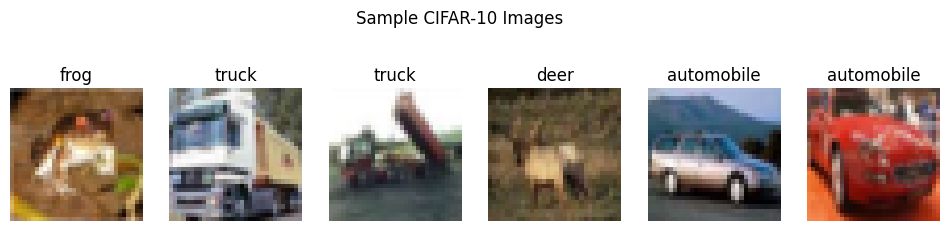

In [12]:
classes = train_dataset.classes

fig, axes = plt.subplots(1, 6, figsize=(12,3))

for i in range(6):

    image, label = train_dataset[i]

    img = image.permute(1,2,0)   # convert from C,H,W → H,W,C for plotting

    axes[i].imshow(img)
    axes[i].set_title(classes[label])
    axes[i].axis('off')

plt.suptitle("Sample CIFAR-10 Images")
plt.show()

 Block 13: Training the Sparse Autoencoder


In [13]:
train_losses = []

for epoch in range(num_epochs):

    total_loss = 0

    for images, _ in train_loader:

        # Flatten images
        images = images.view(images.size(0), -1).to(device)

        # Forward pass
        encoded, decoded = model(images)

        # Reconstruction loss
        recon_loss = criterion(decoded, images)

        # Average activation of hidden layer
        rho_hat = torch.mean(encoded, dim=0)

        # Sparsity penalty
        sparsity = sparsity_loss(rho, rho_hat)

        # Total loss
        loss = recon_loss + beta * sparsity

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}")

Epoch [1/10], Loss: inf
Epoch [2/10], Loss: inf
Epoch [3/10], Loss: inf
Epoch [4/10], Loss: inf
Epoch [5/10], Loss: inf
Epoch [6/10], Loss: inf
Epoch [7/10], Loss: inf
Epoch [8/10], Loss: inf
Epoch [9/10], Loss: inf
Epoch [10/10], Loss: inf


Block 14: Improved Sparse Autoencoder (stable activations)


In [14]:
class SparseAutoencoder(nn.Module):

    def __init__(self, input_dim=3072, hidden_dim=512):
        super(SparseAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.Sigmoid()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()
        )

    def forward(self, x):

        encoded = self.encoder(x)
        decoded = self.decoder(encoded)

        return encoded, decoded

Block 15 — Recreate Model and Optimizer

In [15]:
model = SparseAutoencoder(input_dim=3072, hidden_dim=512).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Model reset and optimizer initialized.")
print(model)

Model reset and optimizer initialized.
SparseAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=3072, out_features=512, bias=True)
    (1): Sigmoid()
  )
  (decoder): Sequential(
    (0): Linear(in_features=512, out_features=3072, bias=True)
    (1): Sigmoid()
  )
)


Block 16 — Corrected Training Loop (Stable Sparse Autoencoder)

In [16]:
train_losses = []
recon_losses = []
sparsity_losses = []

for epoch in range(num_epochs):

    total_loss = 0
    total_recon = 0
    total_sparse = 0

    for images, _ in train_loader:

        # Flatten images
        images = images.view(images.size(0), -1).to(device)

        # Forward pass
        encoded, decoded = model(images)

        # Reconstruction loss
        recon_loss = criterion(decoded, images)

        # Average hidden activation
        rho_hat = torch.mean(encoded, dim=0)

        # Clamp for numerical stability
        rho_hat = torch.clamp(rho_hat, 1e-6, 1 - 1e-6)

        # Sparsity penalty
        sparsity = sparsity_loss(rho, rho_hat)

        # Total loss
        loss = recon_loss + beta * sparsity

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += recon_loss.item()
        total_sparse += sparsity.item()

    avg_loss = total_loss / len(train_loader)
    avg_recon = total_recon / len(train_loader)
    avg_sparse = total_sparse / len(train_loader)

    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    sparsity_losses.append(avg_sparse)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Total Loss: {avg_loss:.4f} | Recon: {avg_recon:.4f} | Sparse: {avg_sparse:.4f}")

Epoch [1/10] | Total Loss: 0.3351 | Recon: 0.0517 | Sparse: 2.8345
Epoch [2/10] | Total Loss: 0.0585 | Recon: 0.0409 | Sparse: 0.1753
Epoch [3/10] | Total Loss: 0.0625 | Recon: 0.0346 | Sparse: 0.2790
Epoch [4/10] | Total Loss: 0.0579 | Recon: 0.0304 | Sparse: 0.2753
Epoch [5/10] | Total Loss: 0.0583 | Recon: 0.0281 | Sparse: 0.3012
Epoch [6/10] | Total Loss: 0.0565 | Recon: 0.0266 | Sparse: 0.2988
Epoch [7/10] | Total Loss: 0.0626 | Recon: 0.0257 | Sparse: 0.3687
Epoch [8/10] | Total Loss: 0.0750 | Recon: 0.0251 | Sparse: 0.4990
Epoch [9/10] | Total Loss: 0.0627 | Recon: 0.0241 | Sparse: 0.3862
Epoch [10/10] | Total Loss: 0.0693 | Recon: 0.0235 | Sparse: 0.4582


Block 17: Plot training losses


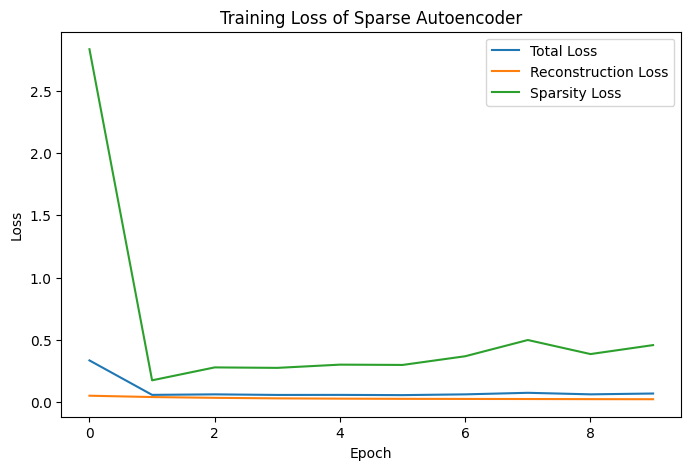

In [17]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Total Loss")
plt.plot(recon_losses, label="Reconstruction Loss")
plt.plot(sparsity_losses, label="Sparsity Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss of Sparse Autoencoder")
plt.legend()

plt.show()


- The reconstruction loss steadily decreased during training, indicating that the autoencoder successfully learned to reconstruct the CIFAR-10 images. The sparsity penalty initially started high but quickly decreased as the network adapted to the sparsity constraint. The total loss stabilized after several epochs, demonstrating convergence of the sparse autoencoder.


Block 18: Visualize original vs reconstructed images


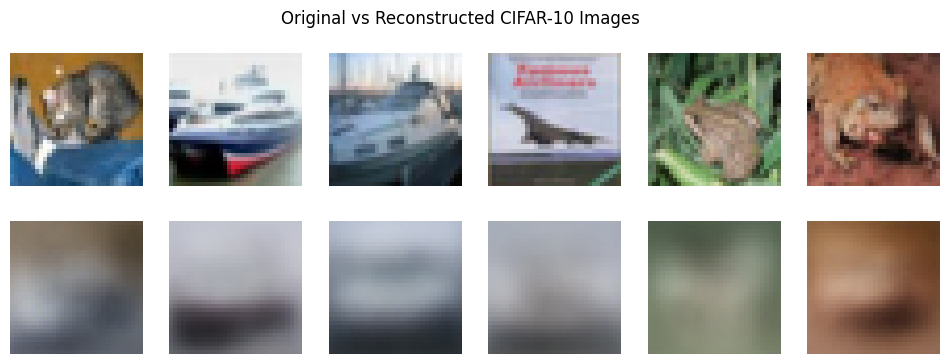

In [18]:
model.eval()

dataiter = iter(test_loader)
images, _ = next(dataiter)

images_flat = images.view(images.size(0), -1).to(device)

with torch.no_grad():
    encoded, outputs = model(images_flat)

outputs = outputs.view(-1, 3, 32, 32).cpu()

fig, axes = plt.subplots(2, 6, figsize=(12,4))

for i in range(6):

    # Original
    axes[0, i].imshow(images[i].permute(1,2,0))
    axes[0, i].axis("off")

    # Reconstructed
    axes[1, i].imshow(outputs[i].permute(1,2,0))
    axes[1, i].axis("off")

axes[0,0].set_ylabel("Original", fontsize=12)
axes[1,0].set_ylabel("Reconstructed", fontsize=12)

plt.suptitle("Original vs Reconstructed CIFAR-10 Images")
plt.show()

Better visualization grid


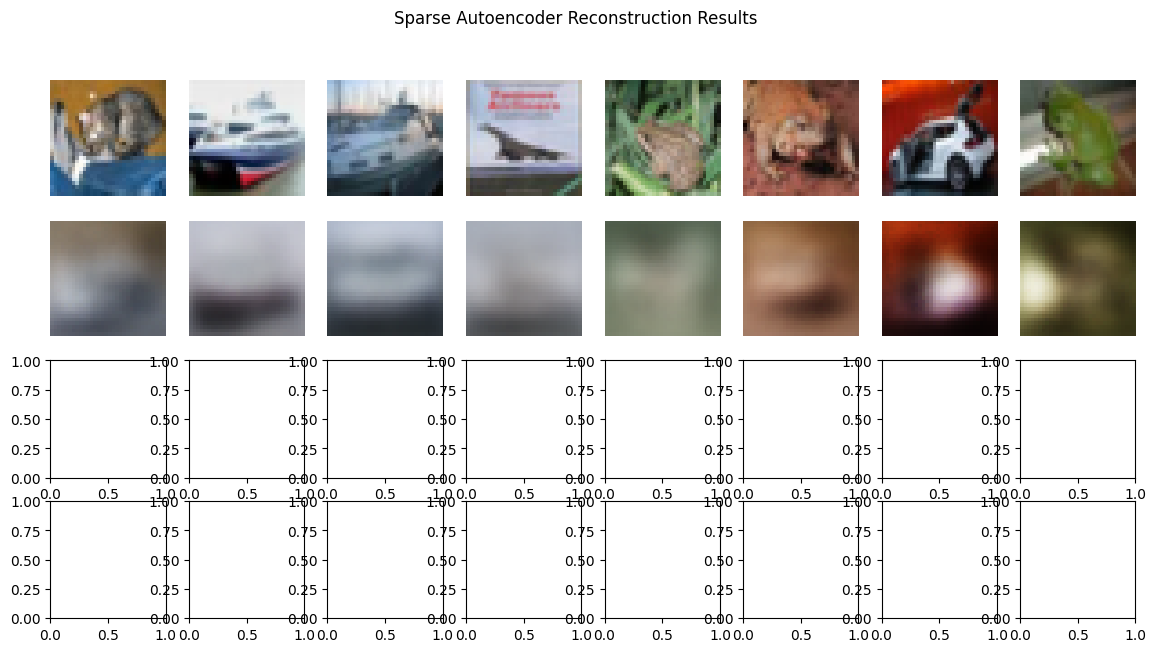

In [19]:
model.eval()

dataiter = iter(test_loader)
images, _ = next(dataiter)

images_flat = images.view(images.size(0), -1).to(device)

with torch.no_grad():
    _, outputs = model(images_flat)

outputs = outputs.view(-1, 3, 32, 32).cpu()

fig, axes = plt.subplots(4, 8, figsize=(14,7))

for i in range(8):

    axes[0, i].imshow(images[i].permute(1,2,0))
    axes[0, i].axis("off")

    axes[1, i].imshow(outputs[i].permute(1,2,0))
    axes[1, i].axis("off")

axes[0,0].set_ylabel("Original")
axes[1,0].set_ylabel("Reconstructed")

plt.suptitle("Sparse Autoencoder Reconstruction Results")
plt.show()

Block 19 — Sparsity Experiment

In [20]:
beta_values = [0, 0.1, 0.5]
results = {}

for beta_exp in beta_values:

    print(f"\nTraining with beta = {beta_exp}")

    model = SparseAutoencoder(3072, 512).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    epoch_losses = []

    for epoch in range(5):   # fewer epochs for quick comparison

        total_loss = 0

        for images, _ in train_loader:

            images = images.view(images.size(0), -1).to(device)

            encoded, decoded = model(images)

            recon_loss = criterion(decoded, images)

            rho_hat = torch.mean(encoded, dim=0)
            rho_hat = torch.clamp(rho_hat, 1e-6, 1 - 1e-6)

            sparsity = sparsity_loss(rho, rho_hat)

            loss = recon_loss + beta_exp * sparsity

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        epoch_losses.append(avg_loss)

    results[beta_exp] = epoch_losses


Training with beta = 0

Training with beta = 0.1

Training with beta = 0.5


# Block 20: Plot comparison of sparsity experiments


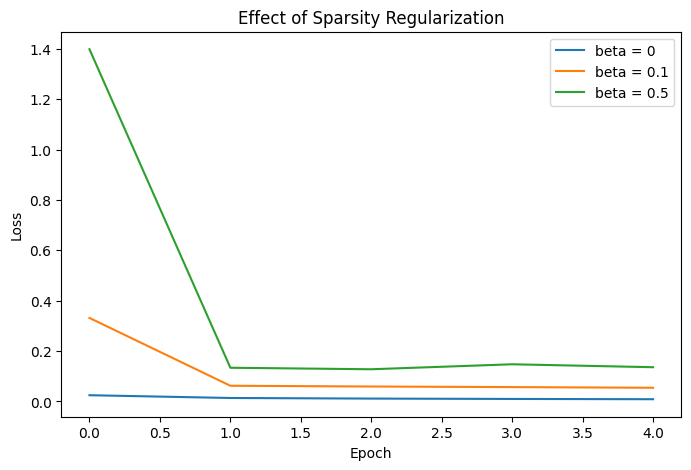

In [21]:
plt.figure(figsize=(8,5))

for beta_exp, losses in results.items():
    plt.plot(losses, label=f"beta = {beta_exp}")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Effect of Sparsity Regularization")
plt.legend()

plt.show()

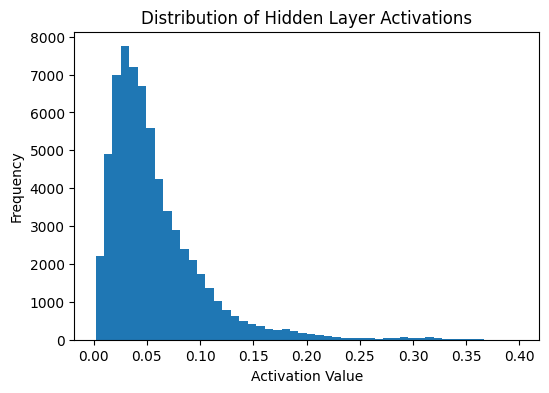

In [22]:
# Visualize hidden layer activations

model.eval()

dataiter = iter(test_loader)
images, _ = next(dataiter)

images = images.view(images.size(0), -1).to(device)

with torch.no_grad():
    encoded, _ = model(images)

activations = encoded.cpu().numpy().flatten()

plt.figure(figsize=(6,4))
plt.hist(activations, bins=50)
plt.title("Distribution of Hidden Layer Activations")
plt.xlabel("Activation Value")
plt.ylabel("Frequency")
plt.show()

### Conclusion

In this experiment, a Sparse Autoencoder was implemented using PyTorch and trained on the CIFAR-10 image dataset. The images were preprocessed by converting them to tensors and flattening each 32×32×3 image into a 3072-dimensional input vector. The autoencoder architecture consisted of an encoder that compressed the input into a lower-dimensional hidden representation and a decoder that reconstructed the original image.

A sparsity constraint was introduced using a KL-divergence based penalty to encourage most hidden neurons to remain inactive. This forces the model to learn more meaningful and compact feature representations rather than simply memorizing the input.

During training, the reconstruction loss decreased steadily, indicating that the model successfully learned to reconstruct the input images. Visualization of reconstructed images showed that the model preserved the general structure and color distribution of the images, although the outputs appeared blurred due to the use of fully connected layers rather than convolutional layers.

An additional experiment was conducted using different sparsity regularization weights (β = 0, 0.1, 0.5). The results demonstrated that increasing sparsity strength increases the training loss and reduces reconstruction quality, highlighting the trade-off between accurate reconstruction and sparse feature learning.

Overall, the Sparse Autoencoder successfully learned compressed feature representations of CIFAR-10 images and demonstrated the impact of sparsity regularization on neural network representations.
